# Trabalho Final - notebook base do projeto da Silvana

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Pergunta de pesquisa

#### **Como fatores de estilo de vida influenciam a duração e a qualidade do sono?**

(atividade física, passos diários e IMC)

--- O sono é um dos principais indicadores de saúde e é afetado pelos hábitos do dia a dia. Neste trabalho será utilizado o conjunto de dados *Sleep Health and Lifestyle*, que reúne informações de 374 pessoas sobre rotina, atividade física e sono. Pretende-se avaliar como o nível de atividade física, a quantidade de passos diários e a faixa de IMC se relacionam com a duração e a qualidade do sono — sem supor de antemão que a relação seja simplesmente "quanto mais, melhor", já que fatores de estilo de vida podem ter efeitos não-lineares sobre o sono.

In [2]:
df = pd.read_csv("../datasets/silvana/Sleep_health_and_lifestyle_dataset.zip", compression='zip')

df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [3]:
df.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='str')

## Classificação das variáveis associadas à pergunta de pesquisa

In [4]:
df["Physical Activity Level"].unique()

array([42, 60, 30, 40, 75, 35, 45, 50, 32, 70, 80, 55, 90, 47, 65, 85])

O nível de atividade física é uma variável **numérica** (minutos de atividade por dia) e varia de 30 a 90 no dataset.

In [5]:
df["Daily Steps"].unique()

array([ 4200, 10000,  3000,  3500,  8000,  4000,  4100,  6800,  5000,
        7000,  5500,  5200,  5600,  3300,  4800,  7500,  7300,  6200,
        6000,  3700])

A quantidade de passos diários é uma variável **numérica** e varia de 3.000 a 10.000 no dataset.

In [6]:
df["BMI Category"].unique()

<StringArray>
['Overweight', 'Normal', 'Obese', 'Normal Weight']
Length: 4, dtype: str

A categoria de IMC é uma variável **categórica** e possui 4 categorias.

In [7]:
df["Sleep Duration"].unique()

array([6.1, 6.2, 5.9, 6.3, 7.8, 6. , 6.5, 7.6, 7.7, 7.9, 6.4, 7.5, 7.2,
       5.8, 6.7, 7.3, 7.4, 7.1, 6.6, 6.9, 8. , 6.8, 8.1, 8.3, 8.5, 8.4,
       8.2])

A duração do sono é uma variável **numérica** (horas por noite) e varia de 5.8 a 8.5 no dataset.

In [8]:
df["Quality of Sleep"].unique()

array([6, 4, 7, 5, 8, 9])

A qualidade do sono é uma variável **numérica** (nota autorreferida) e no dataset varia de 4 a 9. É razoável supor que a escala do questionário original vá de 0 a 10 (ou 1 a 10): esse é o intervalo mais comum para perguntas desse tipo ("dê uma nota de 0 a 10 para..."), e o intervalo observado (4 a 9) cabe inteiramente dentro dele. Ainda assim, isso é uma hipótese, não um dado confirmado no arquivo — o que sabemos com certeza é só o intervalo de 4 a 9 realmente registrado.

## Verificando a qualidade dos dados

In [9]:
# Verificando se há duplicatas

df.duplicated().sum()

np.int64(0)

In [10]:
# Se houver dados duplicados, verificamos quais são:

df[df.duplicated()]

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder


**Conclusão 1:** não há duplicatas no dataset analisado.

In [11]:
# Verificando se há valores faltantes

dados_faltantes_soma = df.isnull().sum()
dados_faltantes_porc = df.isnull().mean() * 100

df_dados_faltantes = pd.DataFrame({"Dados faltantes (soma)": dados_faltantes_soma, "Dados faltantes (porcentagem)": dados_faltantes_porc})
df_dados_faltantes

,Dados faltantes (soma),Dados faltantes (porcentagem)
Person ID,0,0.00000
Gender,0,0.00000
Age,0,0.00000
Occupation,0,0.00000
Sleep Duration,0,0.00000
Quality of Sleep,0,0.00000
Physical Activity Level,0,0.00000
Stress Level,0,0.00000
BMI Category,0,0.00000
Blood Pressure,0,0.00000


**Conclusão 2:** Há valores faltantes em apenas 1 coluna do dataset, Sleep Disorder, com 219 dados faltantes (58.56% da coluna). Essa coluna não é pertinente à pergunta de pesquisa e, além disso, o valor faltante aqui não parece ser um erro: ele indica que a pessoa não tem nenhum distúrbio do sono diagnosticado. Nenhuma das variáveis que serão usadas na análise (atividade física, passos diários, IMC, duração e qualidade do sono) tem dado faltante, então não é preciso apagar nenhuma linha por esse motivo.

Por outro lado, olhando as categorias de IMC identificadas acima, percebe-se que "Normal" e "Normal Weight" são o mesmo grupo escrito de duas formas diferentes, o que divide artificialmente as pessoas de IMC normal em duas categorias e atrapalha a comparação.

## Limpeza do conjunto de dados

In [12]:
# Se houver duplicatas, remove a linha inteira que estiver duplicada
df = df.drop_duplicates()

In [13]:
# Unifica as categorias "Normal" e "Normal Weight", que representam o mesmo grupo
df["BMI Category"] = df["BMI Category"].replace("Normal Weight", "Normal")

df["BMI Category"].value_counts()

BMI Category
Normal        216
Overweight    148
Obese          10
Name: count, dtype: int64

**Conclusão 3:** Na limpeza do dataset, portanto, apenas unifiquei as categorias "Normal" e "Normal Weight" da variável BMI Category, que passou de 4 para 3 categorias. Não apaguei nenhuma linha, porque não há duplicatas e nenhuma variável usada na análise tem dado faltante — a única coluna com valores faltantes, Sleep Disorder, não entra na análise, então não é preciso reconferir os dados faltantes depois da limpeza.

## Estatística descritiva

Utiliza as variáveis categóricas e numéricas identificadas no início do trabalho para calcular estatísticas descritivas pertinentes à pergunta de pesquisa.

In [14]:
# Esta célula cria faixas (variáveis categóricas) a partir de "Physical Activity Level" e
# "Daily Steps", que são numéricas, para poder comparar grupos de pessoas com groupby()
# nas células seguintes — do mesmo jeito que já fazemos com BMI Category
#
# Para "Physical Activity Level" (minutos de atividade por dia) não existe um padrão
# oficial de corte diário: a OMS só recomenda em termos semanais (150 a 300 min/semana),
# então dividimos em tercis (3 grupos de tamanho parecido) pelos próprios dados
#
# Para "Daily Steps" existe uma classificação de saúde pública consolidada (Tudor-Locke,
# 2011 - "How many steps/day are enough?"), que usamos diretamente

# Tercis de atividade física: cada faixa reúne ~1/3 das pessoas da amostra
df["Faixa de Atividade Fisica"], cortes_atividade = pd.qcut(df["Physical Activity Level"], q=3,
                                                            labels=["Baixa", "Média", "Alta"],
                                                            retbins=True)

# Classificação de passos diários (Tudor-Locke, 2011)
df["Faixa de Passos Diarios"] = pd.cut(df["Daily Steps"],
                                       bins=[0, 5000, 7500, 10000, float("inf")],
                                       right=False,
                                       labels=["Sedentário (<5.000)", "Pouco ativo (5.000-7.499)",
                                               "Razoavelmente ativo (7.500-9.999)", "Ativo (≥10.000)"])

# Mostra em que minutos ficaram os cortes dos tercis, já que os rótulos (Baixa/Média/Alta)
# sozinhos não deixam isso explícito
print(f"Cortes dos tercis de atividade física: Baixa = {cortes_atividade[0]:.0f}-{cortes_atividade[1]:.0f} min, "
      f"Média = {cortes_atividade[1]:.0f}-{cortes_atividade[2]:.0f} min, "
      f"Alta = {cortes_atividade[2]:.0f}-{cortes_atividade[3]:.0f} min")

# Confere quantas pessoas caíram em cada faixa
print("\nPessoas por faixa de atividade física (tercis):")
print(df["Faixa de Atividade Fisica"].value_counts())

print("\nPessoas por faixa de passos diários (Tudor-Locke):")
print(df["Faixa de Passos Diarios"].value_counts())

Cortes dos tercis de atividade física: Baixa = 30-45 min, Média = 45-75 min, Alta = 75-90 min

Pessoas por faixa de atividade física (tercis):
Faixa de Atividade Fisica
Média    153
Baixa    150
Alta      71
Name: count, dtype: int64

Pessoas por faixa de passos diários (Tudor-Locke):
Faixa de Passos Diarios
Pouco ativo (5.000-7.499)            216
Razoavelmente ativo (7.500-9.999)    103
Ativo (≥10.000)                       36
Sedentário (<5.000)                   19
Name: count, dtype: int64


In [15]:
# Calcula a média de duração e qualidade do sono em cada faixa de atividade física,
# para ver se quem se exercita mais tende a dormir mais horas e/ou com mais qualidade

df_med_atividade = df.groupby("Faixa de Atividade Fisica", observed=True)[["Sleep Duration", "Quality of Sleep"]].mean()

print("Média de sono por faixa de atividade física:")
print(df_med_atividade)

print("\n################################\n")

# idxmax/idxmax não dizem "sono é alto", e sim qual FAIXA tem a maior média em cada variável
print("Maior média encontrada em cada variável:")
print(df_med_atividade.max())
print("\nFaixa de atividade física correspondente à maior média:")
print(df_med_atividade.idxmax())

print("\n################################\n")

print("Menor média encontrada em cada variável:")
print(df_med_atividade.min())
print("\nFaixa de atividade física correspondente à menor média:")
print(df_med_atividade.idxmin())

Média de sono por faixa de atividade física:
                           Sleep Duration  Quality of Sleep
Faixa de Atividade Fisica                                  
Baixa                            6.812000          6.793333
Média                            7.497386          7.882353
Alta                             7.021127          7.183099

################################

Maior média encontrada em cada variável:
Sleep Duration      7.497386
Quality of Sleep    7.882353
dtype: float64

Faixa de atividade física correspondente à maior média:
Sleep Duration      Média
Quality of Sleep    Média
dtype: category
Categories (3, str): ['Baixa' < 'Média' < 'Alta']

################################

Menor média encontrada em cada variável:
Sleep Duration      6.812000
Quality of Sleep    6.793333
dtype: float64

Faixa de atividade física correspondente à menor média:
Sleep Duration      Baixa
Quality of Sleep    Baixa
dtype: category
Categories (3, str): ['Baixa' < 'Média' < 'Alta']


**Conclusão 4:** Dividindo a atividade física em tercis (Baixa: 30-45 min/dia, Média: 45-75 min/dia, Alta: 75-90 min/dia — cada faixa com cerca de um terço da amostra), a relação com o sono não é uma linha reta. O grupo de atividade **Média** é o que dorme mais (7.50 horas) e com a melhor qualidade (7.88), superando inclusive o grupo de atividade **Alta** (7.02 horas, 7.18 de qualidade). O grupo de atividade **Baixa** é o que dorme menos e pior (6.81 horas, 6.79). Ou seja, mais atividade física está associada a melhor sono só até certo ponto: no topo da distribuição de atividade física desta amostra, o sono piora de novo em vez de continuar melhorando.

In [16]:
# Calcula a média de duração e qualidade do sono em cada faixa de passos diários,
# para ver se andar mais está associado a dormir mais horas e/ou com mais qualidade

df_med_passos = df.groupby("Faixa de Passos Diarios", observed=True)[["Sleep Duration", "Quality of Sleep"]].mean()

print("Média de sono por faixa de passos diários:")
print(df_med_passos)

print("\n################################\n")

print("Maior média encontrada em cada variável:")
print(df_med_passos.max())
print("\nFaixa de passos diários correspondente à maior média:")
print(df_med_passos.idxmax())

print("\n################################\n")

print("Menor média encontrada em cada variável:")
print(df_med_passos.min())
print("\nFaixa de passos diários correspondente à menor média:")
print(df_med_passos.idxmin())

Média de sono por faixa de passos diários:
                                   Sleep Duration  Quality of Sleep
Faixa de Passos Diarios                                            
Sedentário (<5.000)                      6.700000          5.842105
Pouco ativo (5.000-7.499)                7.144444          7.500000
Razoavelmente ativo (7.500-9.999)        7.514563          7.592233
Ativo (≥10.000)                          6.191667          6.166667

################################

Maior média encontrada em cada variável:
Sleep Duration      7.514563
Quality of Sleep    7.592233
dtype: float64

Faixa de passos diários correspondente à maior média:
Sleep Duration      Razoavelmente ativo (7.500-9.999)
Quality of Sleep    Razoavelmente ativo (7.500-9.999)
dtype: category
Categories (4, str): ['Sedentário (<5.000)' < 'Pouco ativo (5.000-7.499)' < 'Razoavelmente ativo (7.500-9.999)' < 'Ativo (≥10.000)']

################################

Menor média encontrada em cada variável:
Sleep Durati

**Conclusão 5:** Usando a classificação de passos diários de Tudor-Locke (2011), o grupo **Razoavelmente ativo** (7.500 a 9.999 passos) tem o melhor sono: 7.51 horas de duração e 7.59 de qualidade. Chama atenção o grupo **Ativo** (10.000 passos ou mais), que tem o pior sono de todos (6.19 horas, 6.17 de qualidade) — pior até que o grupo **Sedentário**. Isso parece contraintuitivo, então investiguei quem forma esse grupo: das 36 pessoas com exatamente 10.000 passos, 32 são enfermeiras, com nível médio de estresse de 7.72 (numa escala em que o restante do dataset varia de 3 a 8). Ou seja, esse resultado provavelmente não mostra que andar muito piora o sono, e sim que, nesta amostra, o grupo de passos mais altos é dominado por uma profissão específica com rotina de trabalho mais estressante — um caso claro de variável de confusão (a profissão), que se mistura com a variável que estamos analisando (passos diários).

In [17]:
# Calcula a média de duração e qualidade do sono em cada categoria de IMC,
# para ver se a categoria de IMC está associada a dormir mais horas e/ou com mais qualidade

df_med_imc = df.groupby("BMI Category")[["Sleep Duration", "Quality of Sleep"]].mean()

print("Média de sono por categoria de IMC:")
print(df_med_imc)

print("\n################################\n")

print("Maior média encontrada em cada variável:")
print(df_med_imc.max())
print("\nCategoria de IMC correspondente à maior média:")
print(df_med_imc.idxmax())

print("\n################################\n")

print("Menor média encontrada em cada variável:")
print(df_med_imc.min())
print("\nCategoria de IMC correspondente à menor média:")
print(df_med_imc.idxmin())

Média de sono por categoria de IMC:
              Sleep Duration  Quality of Sleep
BMI Category                                  
Normal              7.387963          7.638889
Obese               6.960000          6.400000
Overweight          6.770270          6.898649

################################

Maior média encontrada em cada variável:
Sleep Duration      7.387963
Quality of Sleep    7.638889
dtype: float64

Categoria de IMC correspondente à maior média:
Sleep Duration      Normal
Quality of Sleep    Normal
dtype: str

################################

Menor média encontrada em cada variável:
Sleep Duration      6.77027
Quality of Sleep    6.40000
dtype: float64

Categoria de IMC correspondente à menor média:
Sleep Duration      Overweight
Quality of Sleep         Obese
dtype: str


**Conclusão 6:** O IMC é o fator que mais separa os grupos. Quem está na categoria Normal tem a maior média tanto de duração (7.39 horas) quanto de qualidade do sono (7.64). A menor duração média do sono é do grupo Overweight (6.77 horas, cerca de 37 minutos a menos por noite que o grupo Normal) e a pior qualidade média é do grupo Obese (6.40). Vale registrar que o grupo Obese tem apenas 10 pessoas, então essa média é bem menos confiável que as demais.

**Conclusão 7:** Juntando as três comparações, nenhum dos fatores de estilo de vida tem uma relação simples e linear com o sono nesta amostra. O IMC é o que mais separa os grupos de forma consistente (Normal à frente dos demais nos dois indicadores). Já atividade física e passos diários mostram relações não-lineares: o melhor sono aparece em níveis intermediários a moderadamente altos (atividade Média; passos na faixa Razoavelmente ativo), e não no extremo mais alto de cada variável — e no caso dos passos, o pior resultado do extremo mais alto parece se dever a uma variável de confusão (a profissão) e não aos passos em si. Portanto, a resposta preliminar à pergunta de pesquisa é: o sono está associado a estar em uma faixa de IMC normal e a níveis moderados de atividade física, mas a relação com o volume de passos diários é pouco confiável nesta amostra, por estar contaminada pelo efeito da ocupação das pessoas.

## Análise Exploratória

(apenas um "gostinho" no workshop de 29/08 pois isso será explorado no próximo encontro)

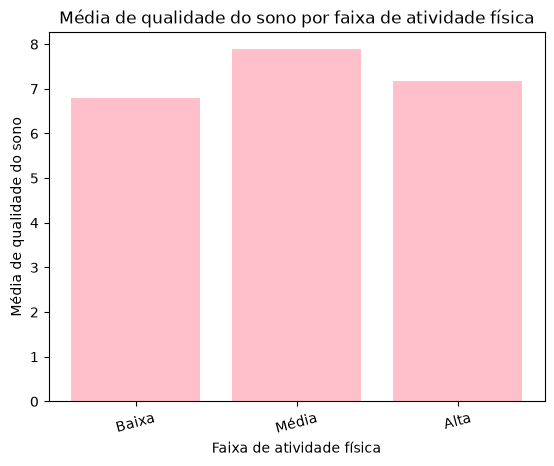

In [18]:
# gráfico de barras

plt.bar(df_med_atividade.index, df_med_atividade["Quality of Sleep"], color="pink")
plt.title("Média de qualidade do sono por faixa de atividade física")
plt.xlabel("Faixa de atividade física")
plt.ylabel("Média de qualidade do sono")
plt.xticks(rotation=15)
plt.show()

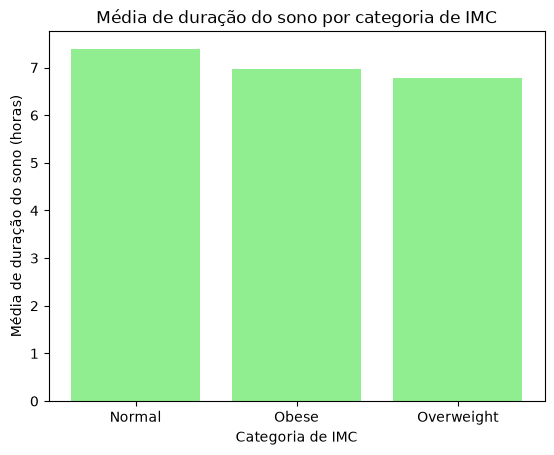

In [19]:
plt.bar(df_med_imc.index, df_med_imc["Sleep Duration"], color="lightgreen")
plt.title("Média de duração do sono por categoria de IMC")
plt.xlabel("Categoria de IMC")
plt.ylabel("Média de duração do sono (horas)")
plt.show()